# Stage 2 — Baseline Feature Engineering

Builds the full feature matrix that will be consumed by Stage 3 statistical anomaly detection.

**Creates:** calendar · cyclical · lag · rolling · historical baseline · day-type baseline · change · building-level reference · per-sqm features

**Input files:**
- `electricity_cleaned.csv` — wide format, one column per building
- `metadata.csv` — building-level attributes
- `outputs/stage1_anomalies.parquet` — Stage 1 anomaly records; used to exclude no-data buildings and mask spike / near-zero flatline readings before feature computation

No anomaly detection, no anomaly scores, no ML models, no weather data.

**Output:** `outputs/stage2_features.parquet` — full feature matrix for Stage 3.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

DATA_DIR  = Path('../../data/building-data-genome-project-2/data')
ELEC_PATH = DATA_DIR / 'meters/cleaned/electricity_cleaned.csv'
META_PATH = DATA_DIR / 'metadata/metadata.csv'

---
## 1. Load Data

In [2]:
elec = pd.read_csv(ELEC_PATH, parse_dates=['timestamp'])
elec.sort_values('timestamp', inplace=True)
elec.reset_index(drop=True, inplace=True)

building_cols = [c for c in elec.columns if c != 'timestamp']

print(f'Shape            : {elec.shape}')
print(f'Timestamps       : {elec.shape[0]:,}')
print(f'Building columns : {len(building_cols):,}')
print(f'Date range       : {elec["timestamp"].min()} → {elec["timestamp"].max()}')

display(elec[['timestamp'] + building_cols[:5]].head())

Shape            : (17544, 1579)
Timestamps       : 17,544
Building columns : 1,578
Date range       : 2016-01-01 00:00:00 → 2017-12-31 23:00:00


,timestamp,Panther_parking_Lorriane,Panther_lodging_Cora,Panther_office_Hannah,Panther_lodging_Hattie,Panther_education_Teofila
0,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1,2016-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN
2,2016-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN
3,2016-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN
4,2016-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN


---
## Stage 1 Integration — Quality Mask

Load Stage 1 anomaly records, drop buildings with `exclude_downstream=True`, then set spike and near-zero flatline readings to NaN in the wide-format dataframe. All subsequent feature computation (lags, rolling stats, baselines, building references) operates on this cleaned data.

In [3]:
STAGE1_PATH = Path('../../outputs/stage1_anomalies.parquet')

anomalies_s1 = pd.read_parquet(STAGE1_PATH)

# Remove no-data buildings (exclude_downstream=True)
exclude_set   = set(anomalies_s1.loc[anomalies_s1['exclude_downstream'], 'building_id'])
building_cols = [c for c in building_cols if c not in exclude_set]
print(f'Buildings excluded (no-data)   : {len(exclude_set)}')
print(f'Buildings remaining            : {len(building_cols)}')

# Mask spike and near-zero flatline readings before any feature computation.
# Long missing runs are already NaN in the source data — no additional masking needed.
MASK_TYPES   = {'spike_extreme_reading', 'near_zero_flatline'}
mask_records = anomalies_s1[
    anomalies_s1['anomaly_type'].isin(MASK_TYPES) &
    anomalies_s1['building_id'].isin(set(building_cols))
]

elec_tmp = elec.set_index('timestamp')

spike_records = mask_records[mask_records['anomaly_type'] == 'spike_extreme_reading']
for bld, grp in spike_records.groupby('building_id'):
    ts_valid = pd.to_datetime(grp['timestamp'])
    ts_valid = ts_valid[ts_valid.isin(elec_tmp.index)]
    if len(ts_valid):
        elec_tmp.loc[ts_valid, bld] = np.nan

nzf_records = mask_records[mask_records['anomaly_type'] == 'near_zero_flatline']
for _, row in nzf_records.iterrows():
    bld  = row['building_id']
    span = (elec_tmp.index >= row['start_time']) & (elec_tmp.index <= row['end_time'])
    elec_tmp.loc[span, bld] = np.nan

elec = elec_tmp.reset_index()

print(f'Spike readings masked          : {len(spike_records):,}')
print(f'Near-zero flatline runs masked : {len(nzf_records):,}')
print(f'Electricity dataframe shape    : {elec.shape}')

Buildings excluded (no-data)   : 13
Buildings remaining            : 1565
Spike readings masked          : 25,270
Near-zero flatline runs masked : 363
Electricity dataframe shape    : (17544, 1579)


---
## 2. Create Long Format Dataset

Melt from wide (one column per building) to long (one row per building-timestamp pair).

In [4]:
long_df = elec.melt(id_vars=['timestamp'], var_name='building_id', value_name='consumption')
long_df.sort_values(['building_id', 'timestamp'], inplace=True)
long_df.reset_index(drop=True, inplace=True)

mem_mb = long_df.memory_usage(deep=True).sum() / 1e6

print(f'Shape        : {long_df.shape}')
print(f'Memory usage : {mem_mb:.1f} MB')

display(long_df.head(10))

Shape        : (27684432, 3)
Memory usage : 1217.6 MB


,timestamp,building_id,consumption
0,2016-01-01 00:00:00,Bear_assembly_Angel,237.850
1,2016-01-01 01:00:00,Bear_assembly_Angel,221.250
2,2016-01-01 02:00:00,Bear_assembly_Angel,222.500
3,2016-01-01 03:00:00,Bear_assembly_Angel,221.400
4,2016-01-01 04:00:00,Bear_assembly_Angel,224.250
5,2016-01-01 05:00:00,Bear_assembly_Angel,241.262
6,2016-01-01 06:00:00,Bear_assembly_Angel,261.300
7,2016-01-01 07:00:00,Bear_assembly_Angel,481.450
8,2016-01-01 08:00:00,Bear_assembly_Angel,477.400
9,2016-01-01 09:00:00,Bear_assembly_Angel,485.400


---
## 3. Add Metadata

Left-join selected metadata columns onto the long dataset.

In [5]:
META_KEEP = ['building_id', 'site_id', 'primaryspaceusage', 'sqm', 'lat', 'lng', 'timezone']

meta     = pd.read_csv(META_PATH)
meta_sub = meta[[c for c in META_KEEP if c in meta.columns]].copy()

long_df = long_df.merge(meta_sub, on='building_id', how='left')

print(f'Shape after join : {long_df.shape}')
print('\nMissing metadata counts:')
display(
    long_df[[c for c in META_KEEP if c in long_df.columns]]
    .isna().sum().rename('missing').to_frame()
)
display(long_df.head())

Shape after join : (27684432, 9)

Missing metadata counts:


,missing
building_id,0
site_id,0
primaryspaceusage,333336
sqm,0
lat,4105296
lng,4105296
timezone,0


,timestamp,building_id,consumption,site_id,primaryspaceusage,sqm,lat,lng,timezone
0,2016-01-01 00:00:00,Bear_assembly_Angel,237.85,Bear,Entertainment/public assembly,22117.0,37.871903,-122.260729,US/Pacific
1,2016-01-01 01:00:00,Bear_assembly_Angel,221.25,Bear,Entertainment/public assembly,22117.0,37.871903,-122.260729,US/Pacific
2,2016-01-01 02:00:00,Bear_assembly_Angel,222.50,Bear,Entertainment/public assembly,22117.0,37.871903,-122.260729,US/Pacific
3,2016-01-01 03:00:00,Bear_assembly_Angel,221.40,Bear,Entertainment/public assembly,22117.0,37.871903,-122.260729,US/Pacific
4,2016-01-01 04:00:00,Bear_assembly_Angel,224.25,Bear,Entertainment/public assembly,22117.0,37.871903,-122.260729,US/Pacific


---
## 4. Calendar Features

,timestamp,hour,day_of_week,month,quarter,year,day_of_year,week_of_year,is_weekend
0,2016-01-01 00:00:00,0,4,1,1,2016,1,53,0
1,2016-01-01 01:00:00,1,4,1,1,2016,1,53,0
2,2016-01-01 02:00:00,2,4,1,1,2016,1,53,0
3,2016-01-01 03:00:00,3,4,1,1,2016,1,53,0
4,2016-01-01 04:00:00,4,4,1,1,2016,1,53,0


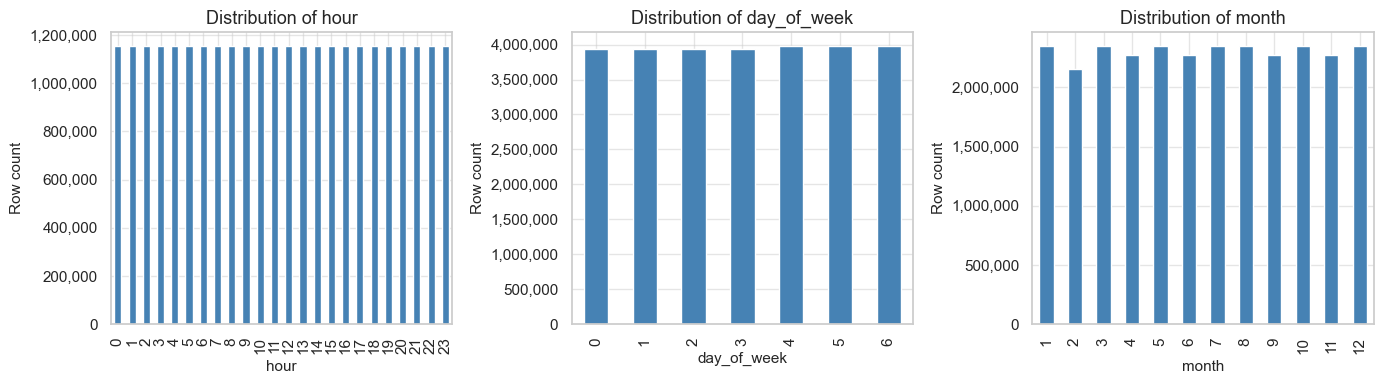

In [6]:
ts = long_df['timestamp']

long_df['hour']         = ts.dt.hour
long_df['day_of_week']  = ts.dt.dayofweek
long_df['month']        = ts.dt.month
long_df['quarter']      = ts.dt.quarter
long_df['year']         = ts.dt.year
long_df['day_of_year']  = ts.dt.dayofyear
long_df['week_of_year'] = ts.dt.isocalendar().week.astype(int)
long_df['is_weekend']   = (long_df['day_of_week'] >= 5).astype(int)

cal_cols = [
    'hour', 'day_of_week', 'month', 'quarter',
    'year', 'day_of_year', 'week_of_year', 'is_weekend',
]
display(long_df[['timestamp'] + cal_cols].head())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['hour', 'day_of_week', 'month']):
    long_df[col].value_counts().sort_index().plot.bar(
        ax=ax, color='steelblue', edgecolor='white'
    )
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Row count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

---
## 5. Cyclical Features

Encode hour and month as (sin, cos) pairs so the model sees continuity at boundaries (23→0 h, Dec→Jan).

,timestamp,hour,hour_sin,hour_cos,month,month_sin,month_cos
0,2016-01-01 00:00:00,0,0.000000e+00,1.000000e+00,1,0.5,0.866025
1,2016-01-01 01:00:00,1,2.588190e-01,9.659258e-01,1,0.5,0.866025
2,2016-01-01 02:00:00,2,5.000000e-01,8.660254e-01,1,0.5,0.866025
3,2016-01-01 03:00:00,3,7.071068e-01,7.071068e-01,1,0.5,0.866025
4,2016-01-01 04:00:00,4,8.660254e-01,5.000000e-01,1,0.5,0.866025
5,2016-01-01 05:00:00,5,9.659258e-01,2.588190e-01,1,0.5,0.866025
6,2016-01-01 06:00:00,6,1.000000e+00,6.123234e-17,1,0.5,0.866025
7,2016-01-01 07:00:00,7,9.659258e-01,-2.588190e-01,1,0.5,0.866025
8,2016-01-01 08:00:00,8,8.660254e-01,-5.000000e-01,1,0.5,0.866025
9,2016-01-01 09:00:00,9,7.071068e-01,-7.071068e-01,1,0.5,0.866025


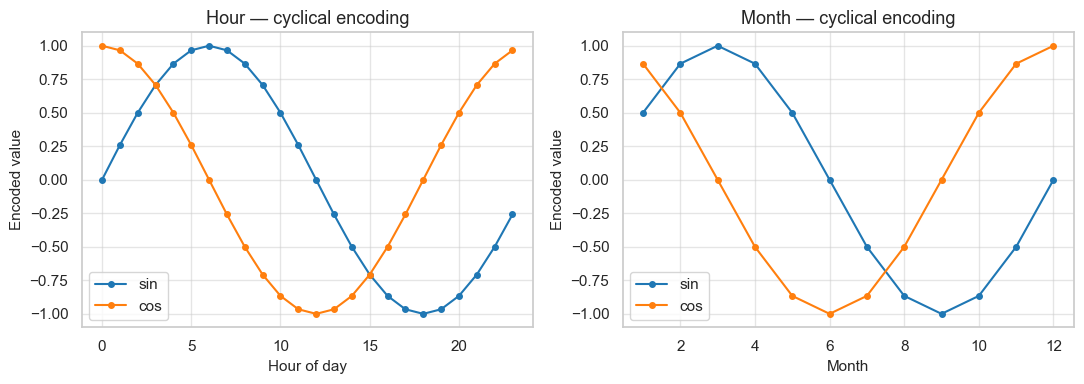

In [7]:
long_df['hour_sin']  = np.sin(2 * np.pi * long_df['hour']  / 24)
long_df['hour_cos']  = np.cos(2 * np.pi * long_df['hour']  / 24)
long_df['month_sin'] = np.sin(2 * np.pi * long_df['month'] / 12)
long_df['month_cos'] = np.cos(2 * np.pi * long_df['month'] / 12)

display(
    long_df[['timestamp', 'hour', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos']]
    .drop_duplicates('hour').sort_values('hour').head(24)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

hours = np.arange(24)
axes[0].plot(hours, np.sin(2 * np.pi * hours / 24), label='sin', marker='o', markersize=4)
axes[0].plot(hours, np.cos(2 * np.pi * hours / 24), label='cos', marker='o', markersize=4)
axes[0].set_title('Hour — cyclical encoding')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Encoded value')
axes[0].legend()

months = np.arange(1, 13)
axes[1].plot(months, np.sin(2 * np.pi * months / 12), label='sin', marker='o', markersize=4)
axes[1].plot(months, np.cos(2 * np.pi * months / 12), label='cos', marker='o', markersize=4)
axes[1].set_title('Month — cyclical encoding')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Encoded value')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6. Lag Features

| Feature | Meaning |
|---|---|
| `lag_1h` | Previous hour |
| `lag_24h` | Same hour yesterday |
| `lag_168h` | Same hour last week |

Computed within each building group so lags never cross building boundaries.

In [8]:
grp = long_df.groupby('building_id', sort=False)['consumption']

long_df['lag_1h']   = grp.shift(1)
long_df['lag_24h']  = grp.shift(24)
long_df['lag_168h'] = grp.shift(168)

lag_cols = ['lag_1h', 'lag_24h', 'lag_168h']

display(
    long_df[['timestamp', 'building_id', 'consumption'] + lag_cols]
    .head(170)
    .tail(10)
)

print('\nPercentage of missing lag values:')
display(
    long_df[lag_cols].isna().mean().mul(100).round(3)
    .rename('missing_%').to_frame()
)

,timestamp,building_id,consumption,lag_1h,lag_24h,lag_168h
160,2016-01-07 16:00:00,Bear_assembly_Angel,754.90,730.60,754.60,NaN
161,2016-01-07 17:00:00,Bear_assembly_Angel,738.95,754.90,750.35,NaN
162,2016-01-07 18:00:00,Bear_assembly_Angel,607.70,738.95,739.70,NaN
163,2016-01-07 19:00:00,Bear_assembly_Angel,346.05,607.70,484.25,NaN
164,2016-01-07 20:00:00,Bear_assembly_Angel,292.10,346.05,400.30,NaN
165,2016-01-07 21:00:00,Bear_assembly_Angel,270.00,292.10,280.30,NaN
166,2016-01-07 22:00:00,Bear_assembly_Angel,244.65,270.00,246.90,NaN
167,2016-01-07 23:00:00,Bear_assembly_Angel,237.70,244.65,242.60,NaN
168,2016-01-08 00:00:00,Bear_assembly_Angel,231.80,237.70,237.45,237.85
169,2016-01-08 01:00:00,Bear_assembly_Angel,217.65,231.80,223.40,221.25



Percentage of missing lag values:


,missing_%
lag_1h,11.019
lag_24h,11.133
lag_168h,11.852


---
## 7. Rolling Statistics

24 h and 168 h windows.  
Uses `.rolling(...).agg().shift(1)` to include only **past** observations — no data leakage.

In [9]:
grp = long_df.groupby('building_id', sort=False)['consumption']

long_df['rolling_mean_24h']    = grp.transform(lambda x: x.rolling(24,  min_periods=1).mean().shift(1))
long_df['rolling_median_24h']  = grp.transform(lambda x: x.rolling(24,  min_periods=1).median().shift(1))
long_df['rolling_std_24h']     = grp.transform(lambda x: x.rolling(24,  min_periods=1).std().shift(1))

long_df['rolling_mean_168h']   = grp.transform(lambda x: x.rolling(168, min_periods=1).mean().shift(1))
long_df['rolling_median_168h'] = grp.transform(lambda x: x.rolling(168, min_periods=1).median().shift(1))
long_df['rolling_std_168h']    = grp.transform(lambda x: x.rolling(168, min_periods=1).std().shift(1))

roll_cols = [
    'rolling_mean_24h', 'rolling_median_24h', 'rolling_std_24h',
    'rolling_mean_168h', 'rolling_median_168h', 'rolling_std_168h',
]

display(long_df[['timestamp', 'building_id', 'consumption'] + roll_cols].head())
print('\nSummary statistics:')
display(long_df[roll_cols].describe().round(4))

,timestamp,building_id,consumption,rolling_mean_24h,rolling_median_24h,rolling_std_24h,rolling_mean_168h,rolling_median_168h,rolling_std_168h
0,2016-01-01 00:00:00,Bear_assembly_Angel,237.85,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-01 01:00:00,Bear_assembly_Angel,221.25,237.85,237.85,NaN,237.85,237.85,NaN
2,2016-01-01 02:00:00,Bear_assembly_Angel,222.50,229.55,229.55,11.737973,229.55,229.55,11.737973
3,2016-01-01 03:00:00,Bear_assembly_Angel,221.40,227.20,222.50,9.244323,227.20,222.50,9.244323
4,2016-01-01 04:00:00,Bear_assembly_Angel,224.25,225.75,221.95,8.085893,225.75,221.95,8.085893



Summary statistics:


,rolling_mean_24h,rolling_median_24h,rolling_std_24h,rolling_mean_168h,rolling_median_168h,rolling_std_168h
count,2.492354e+07,2.492354e+07,2.488141e+07,2.521102e+07,2.521102e+07,2.517180e+07
mean,1.458724e+02,1.445626e+02,2.328430e+01,1.456715e+02,1.399272e+02,2.845350e+01
std,2.427684e+02,2.423747e+02,4.154800e+01,2.422784e+02,2.374240e+02,4.700460e+01
min,1.000000e-04,1.000000e-04,0.000000e+00,1.000000e-04,1.000000e-04,0.000000e+00
25%,2.208670e+01,2.084170e+01,3.205500e+00,2.225920e+01,2.000000e+01,5.298100e+00
50%,6.366670e+01,6.161660e+01,1.029780e+01,6.377020e+01,5.900000e+01,1.413820e+01
75%,1.585901e+02,1.592500e+02,2.726790e+01,1.574632e+02,1.527294e+02,3.325330e+01
max,3.098000e+03,3.098000e+03,1.269974e+03,3.096300e+03,3.096300e+03,1.227903e+03


---
## 8. Historical Baseline Features

For each (building, hour) pair compute an **expanding** median/mean/std using only past observations.  
Row *i* receives the statistic computed from all prior rows with the same building and hour.

In [10]:
grp_bh = long_df.groupby(['building_id', 'hour'], sort=False)['consumption']

long_df['historical_hour_median'] = grp_bh.transform(
    lambda x: x.expanding(min_periods=1).median().shift(1)
)
long_df['historical_hour_mean'] = grp_bh.transform(
    lambda x: x.expanding(min_periods=1).mean().shift(1)
)
long_df['historical_hour_std'] = grp_bh.transform(
    lambda x: x.expanding(min_periods=1).std().shift(1)
)

hist_cols = ['historical_hour_median', 'historical_hour_mean', 'historical_hour_std']

display(
    long_df[['timestamp', 'building_id', 'hour', 'consumption'] + hist_cols]
    .head(25)
)
print('\nDescriptive statistics:')
display(long_df[hist_cols].describe().round(4))

,timestamp,building_id,hour,consumption,historical_hour_median,historical_hour_mean,historical_hour_std
0,2016-01-01 00:00:00,Bear_assembly_Angel,0,237.850,NaN,NaN,NaN
1,2016-01-01 01:00:00,Bear_assembly_Angel,1,221.250,NaN,NaN,NaN
2,2016-01-01 02:00:00,Bear_assembly_Angel,2,222.500,NaN,NaN,NaN
3,2016-01-01 03:00:00,Bear_assembly_Angel,3,221.400,NaN,NaN,NaN
4,2016-01-01 04:00:00,Bear_assembly_Angel,4,224.250,NaN,NaN,NaN
5,2016-01-01 05:00:00,Bear_assembly_Angel,5,241.262,NaN,NaN,NaN
6,2016-01-01 06:00:00,Bear_assembly_Angel,6,261.300,NaN,NaN,NaN
7,2016-01-01 07:00:00,Bear_assembly_Angel,7,481.450,NaN,NaN,NaN
8,2016-01-01 08:00:00,Bear_assembly_Angel,8,477.400,NaN,NaN,NaN
9,2016-01-01 09:00:00,Bear_assembly_Angel,9,485.400,NaN,NaN,NaN



Descriptive statistics:


,historical_hour_median,historical_hour_mean,historical_hour_std
count,2.666990e+07,2.666990e+07,2.660347e+07
mean,1.422825e+02,1.431688e+02,2.852430e+01
std,2.370377e+02,2.369253e+02,5.199140e+01
min,2.000000e-04,2.000000e-04,0.000000e+00
25%,2.015000e+01,2.102550e+01,5.242100e+00
50%,6.121800e+01,6.270070e+01,1.356880e+01
75%,1.565000e+02,1.568718e+02,3.077660e+01
max,3.030000e+03,2.875233e+03,1.060199e+03


---
## 9. Day-Type Baseline Features

Splits the historical baseline by weekday vs weekend to capture the different consumption patterns.

In [11]:
grp_bhw = long_df.groupby(['building_id', 'hour', 'is_weekend'], sort=False)['consumption']

long_df['historical_hour_daytype_median'] = grp_bhw.transform(
    lambda x: x.expanding(min_periods=1).median().shift(1)
)

display(
    long_df[
        ['timestamp', 'building_id', 'hour', 'is_weekend',
         'consumption', 'historical_hour_median', 'historical_hour_daytype_median']
    ].head(25)
)

,timestamp,building_id,hour,is_weekend,consumption,historical_hour_median,historical_hour_daytype_median
0,2016-01-01 00:00:00,Bear_assembly_Angel,0,0,237.850,NaN,NaN
1,2016-01-01 01:00:00,Bear_assembly_Angel,1,0,221.250,NaN,NaN
2,2016-01-01 02:00:00,Bear_assembly_Angel,2,0,222.500,NaN,NaN
3,2016-01-01 03:00:00,Bear_assembly_Angel,3,0,221.400,NaN,NaN
4,2016-01-01 04:00:00,Bear_assembly_Angel,4,0,224.250,NaN,NaN
5,2016-01-01 05:00:00,Bear_assembly_Angel,5,0,241.262,NaN,NaN
6,2016-01-01 06:00:00,Bear_assembly_Angel,6,0,261.300,NaN,NaN
7,2016-01-01 07:00:00,Bear_assembly_Angel,7,0,481.450,NaN,NaN
8,2016-01-01 08:00:00,Bear_assembly_Angel,8,0,477.400,NaN,NaN
9,2016-01-01 09:00:00,Bear_assembly_Angel,9,0,485.400,NaN,NaN


---
## 10. Consumption Change Features

,timestamp,building_id,consumption,delta_1h,pct_change_1h,delta_24h,pct_change_24h
0,2016-01-01 00:00:00,Bear_assembly_Angel,237.85,NaN,NaN,NaN,NaN
1,2016-01-01 01:00:00,Bear_assembly_Angel,221.25,-16.60,-6.979189,NaN,NaN
2,2016-01-01 02:00:00,Bear_assembly_Angel,222.50,1.25,0.564972,NaN,NaN
3,2016-01-01 03:00:00,Bear_assembly_Angel,221.40,-1.10,-0.494382,NaN,NaN
4,2016-01-01 04:00:00,Bear_assembly_Angel,224.25,2.85,1.287263,NaN,NaN



Summary statistics:


,delta_1h,pct_change_1h,delta_24h,pct_change_24h
count,2.458374e+07,2.406915e+07,2.440205e+07,2.390234e+07
mean,-2.310000e-02,1.588700e+00,-7.300000e-03,6.880700e+00
std,2.194530e+01,5.615340e+01,4.781750e+01,1.431874e+02
min,-2.487000e+03,-9.999920e+01,-2.542320e+03,-9.999980e+01
25%,-2.000000e+00,-3.136300e+00,-3.800000e+00,-6.060600e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.536000e+00,2.781900e+00,3.189600e+00,5.677500e+00
max,3.010000e+03,6.543333e+04,2.669060e+03,6.136371e+04


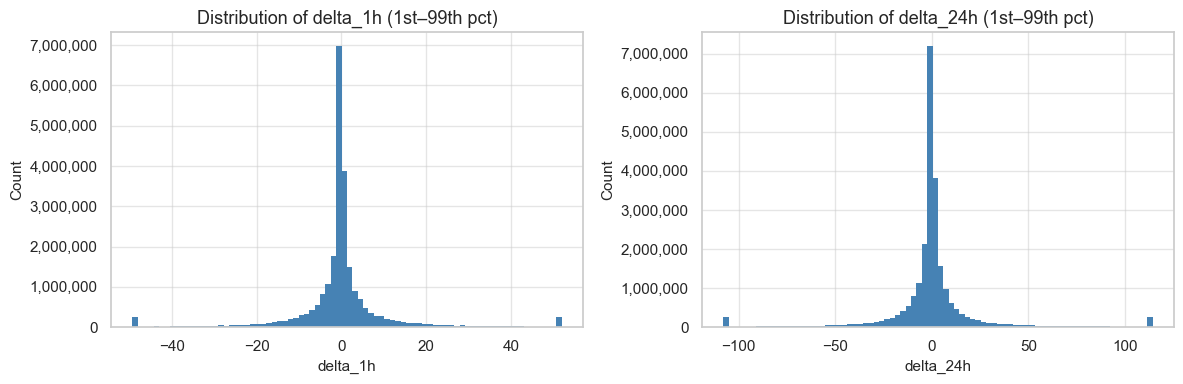

In [12]:
NEAR_ZERO_THRESHOLD = 1.0  # kWh — lag values below this produce unreliable pct_change

long_df['delta_1h']  = long_df['consumption'] - long_df['lag_1h']
long_df['delta_24h'] = long_df['consumption'] - long_df['lag_24h']

denom_1h  = long_df['lag_1h'].where(long_df['lag_1h'].abs()  >= NEAR_ZERO_THRESHOLD)
denom_24h = long_df['lag_24h'].where(long_df['lag_24h'].abs() >= NEAR_ZERO_THRESHOLD)

long_df['pct_change_1h']  = long_df['delta_1h']  / denom_1h  * 100
long_df['pct_change_24h'] = long_df['delta_24h'] / denom_24h * 100

chg_cols = ['delta_1h', 'pct_change_1h', 'delta_24h', 'pct_change_24h']

display(long_df[['timestamp', 'building_id', 'consumption'] + chg_cols].head())
print('\nSummary statistics:')
display(long_df[chg_cols].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['delta_1h', 'delta_24h']):
    data = long_df[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    data.clip(lo, hi).hist(ax=ax, bins=80, color='steelblue', edgecolor='none')
    ax.set_title(f'Distribution of {col} (1st–99th pct)')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

---
## 11. Building-Level Reference Features

Aggregate statistics computed over the full history of each building and merged back as constant columns.

In [13]:
bld_stats = (
    long_df.groupby('building_id')['consumption']
    .agg(
        building_mean='mean',
        building_median='median',
        building_std='std',
        building_p95=lambda x: x.quantile(0.95),
        building_p99=lambda x: x.quantile(0.99),
    )
    .reset_index()
)

long_df = long_df.merge(bld_stats, on='building_id', how='left')

ref_cols = ['building_mean', 'building_median', 'building_std', 'building_p95', 'building_p99']

display(
    long_df[['building_id'] + ref_cols]
    .drop_duplicates('building_id')
    .sort_values('building_mean', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

,building_id,building_mean,building_median,building_std,building_p95,building_p99
0,Hog_education_Janell,2651.444195,2619.6000,253.821410,3057.10000,3089.685000
1,Fox_education_Willis,2432.376533,2352.5300,241.942134,2927.30400,3033.459600
2,Rat_office_Colby,2112.192344,2151.7700,385.700448,2600.52800,2679.728400
3,Bear_education_Wilton,1565.910354,1542.8773,169.415368,1879.38369,2057.388506
4,Eagle_education_Peter,1554.733408,1517.2067,164.329504,1850.06870,1911.115040
5,Moose_education_Diane,1491.638625,1496.1401,163.538484,1756.38806,1999.723800
6,Hog_office_Nia,1452.976829,1333.5520,479.382479,2472.57260,2664.450840
7,Rat_health_Guy,1450.261010,1398.2400,270.068485,1907.85600,1981.440000
8,Hog_office_Cornell,1414.001799,1348.0460,404.017529,2206.06225,2539.412750
9,Bear_education_Bulah,1333.268339,1303.7200,142.601708,1600.50000,1744.160000


---
## 12. Consumption Normalization

Create `consumption_per_sqm` when `sqm` is available.

consumption_per_sqm created.
Non-null rows: 24,635,328


,consumption_per_sqm
count,2.463533e+07
mean,1.995098e-02
std,3.186913e-02
min,2.667378e-08
25%,6.954902e-03
50%,1.289492e-02
75%,2.300639e-02
max,1.757035e+00


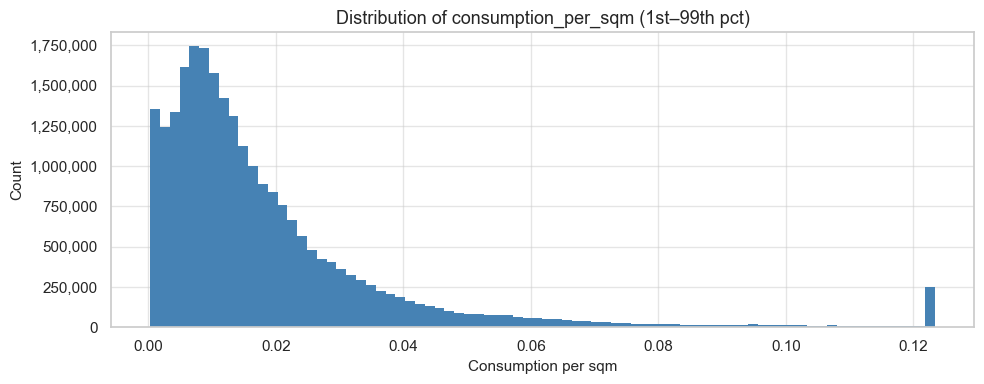

In [14]:
if 'sqm' in long_df.columns and long_df['sqm'].notna().any():
    long_df['consumption_per_sqm'] = long_df['consumption'] / long_df['sqm']
    print('consumption_per_sqm created.')
    print(f'Non-null rows: {long_df["consumption_per_sqm"].notna().sum():,}')
    display(long_df['consumption_per_sqm'].describe().rename('consumption_per_sqm').to_frame())

    data = long_df['consumption_per_sqm'].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)

    fig, ax = plt.subplots(figsize=(10, 4))
    data.clip(lo, hi).hist(ax=ax, bins=80, color='steelblue', edgecolor='none')
    ax.set_title('Distribution of consumption_per_sqm (1st–99th pct)')
    ax.set_xlabel('Consumption per sqm')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()
else:
    print('sqm not available — skipping consumption_per_sqm.')

---
## 13. Feature Quality Check

Missing rate, mean, std, min, max for every engineered feature. Sorted by missing rate descending.

In [15]:
feature_cols = [
    'hour', 'day_of_week', 'month', 'quarter', 'year',
    'day_of_year', 'week_of_year', 'is_weekend',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'lag_1h', 'lag_24h', 'lag_168h',
    'rolling_mean_24h', 'rolling_median_24h', 'rolling_std_24h',
    'rolling_mean_168h', 'rolling_median_168h', 'rolling_std_168h',
    'historical_hour_median', 'historical_hour_mean', 'historical_hour_std',
    'historical_hour_daytype_median',
    'delta_1h', 'pct_change_1h', 'delta_24h', 'pct_change_24h',
    'building_mean', 'building_median', 'building_std', 'building_p95', 'building_p99',
]
if 'consumption_per_sqm' in long_df.columns:
    feature_cols.append('consumption_per_sqm')

quality_rows = []
for col in feature_cols:
    s = long_df[col]
    quality_rows.append({
        'feature':      col,
        'missing_rate': s.isna().mean(),
        'mean':         s.mean(),
        'std':          s.std(),
        'min':          s.min(),
        'max':          s.max(),
    })

quality = (
    pd.DataFrame(quality_rows)
    .sort_values('missing_rate', ascending=False)
    .reset_index(drop=True)
)

pd.set_option('display.float_format', '{:.4f}'.format)
display(quality)
pd.reset_option('display.float_format')

,feature,missing_rate,mean,std,min,max
0,pct_change_24h,0.1366,6.8807,143.1874,-99.9998,61363.7117
1,pct_change_1h,0.1306,1.5887,56.1534,-99.9992,65433.3333
2,delta_24h,0.1186,-0.0073,47.8175,-2542.3200,2669.0600
3,lag_168h,0.1185,145.4460,242.8074,0.0001,3098.4800
4,delta_1h,0.1120,-0.0231,21.9453,-2487.0000,3010.0000
5,lag_24h,0.1113,145.3094,242.6210,0.0001,3098.4800
6,lag_1h,0.1102,145.2856,242.5918,0.0001,3098.4800
7,consumption_per_sqm,0.1101,0.0200,0.0319,0.0000,1.7570
8,rolling_std_24h,0.1012,23.2843,41.5480,0.0000,1269.9736
9,rolling_median_24h,0.0997,144.5626,242.3747,0.0001,3098.0000


---
## 14. Correlation Review

Rows used for correlation (complete cases): 23,827,103


,consumption,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_mean_168h,historical_hour_median,historical_hour_daytype_median
consumption,1.000,0.996,0.980,0.977,0.978,0.972,0.959,0.964
lag_1h,0.996,1.000,0.979,0.974,0.979,0.972,0.958,0.963
lag_24h,0.980,0.979,1.000,0.970,0.979,0.974,0.959,0.957
lag_168h,0.977,0.974,0.970,1.000,0.965,0.972,0.960,0.965
rolling_mean_24h,0.978,0.979,0.979,0.965,1.000,0.992,0.953,0.954
rolling_mean_168h,0.972,0.972,0.974,0.972,0.992,1.000,0.960,0.957
historical_hour_median,0.959,0.958,0.959,0.960,0.953,0.960,1.000,0.993
historical_hour_daytype_median,0.964,0.963,0.957,0.965,0.954,0.957,0.993,1.000


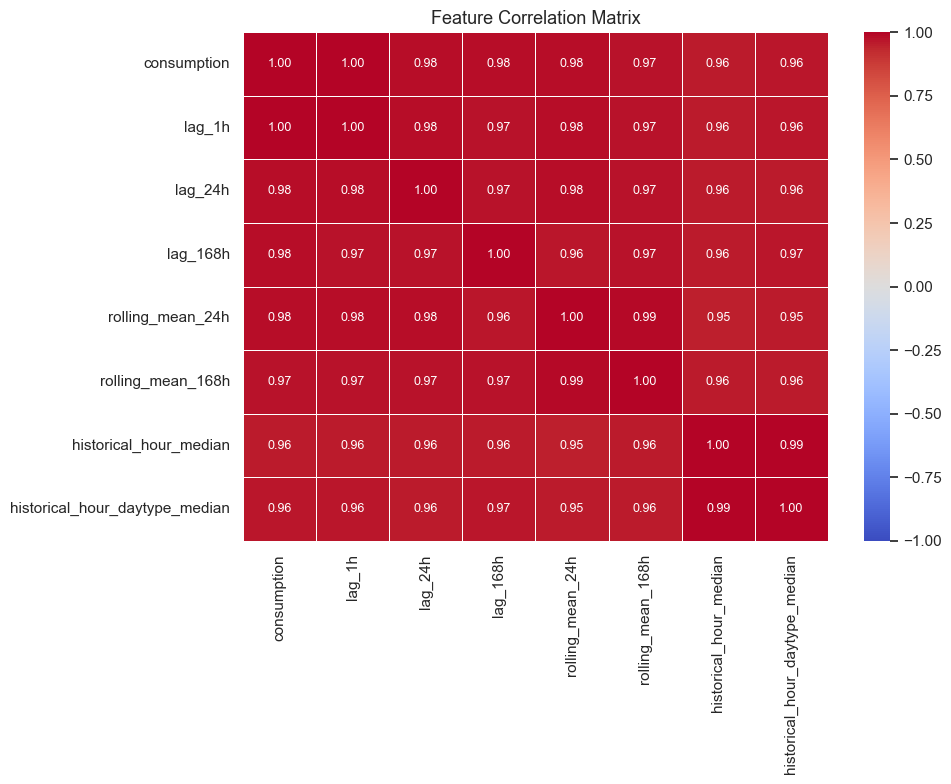

In [16]:
corr_cols = [
    'consumption',
    'lag_1h', 'lag_24h', 'lag_168h',
    'rolling_mean_24h', 'rolling_mean_168h',
    'historical_hour_median', 'historical_hour_daytype_median',
]

corr_sample = long_df[corr_cols].dropna(how='any')
print(f'Rows used for correlation (complete cases): {len(corr_sample):,}')

corr_matrix = corr_sample.corr()
display(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, ax=ax,
    annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={'size': 9},
)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

---
## 15. Representative Building Review

Overlay consumption, lag_24h, rolling_mean_24h, and historical_hour_median to visually verify that engineered features make sense.

Representative buildings found: ['Bear_education_Alfredo', 'Bear_education_Deborah', 'Bear_education_Lashanda', 'Bear_education_Santos', 'Bear_education_Wilton']


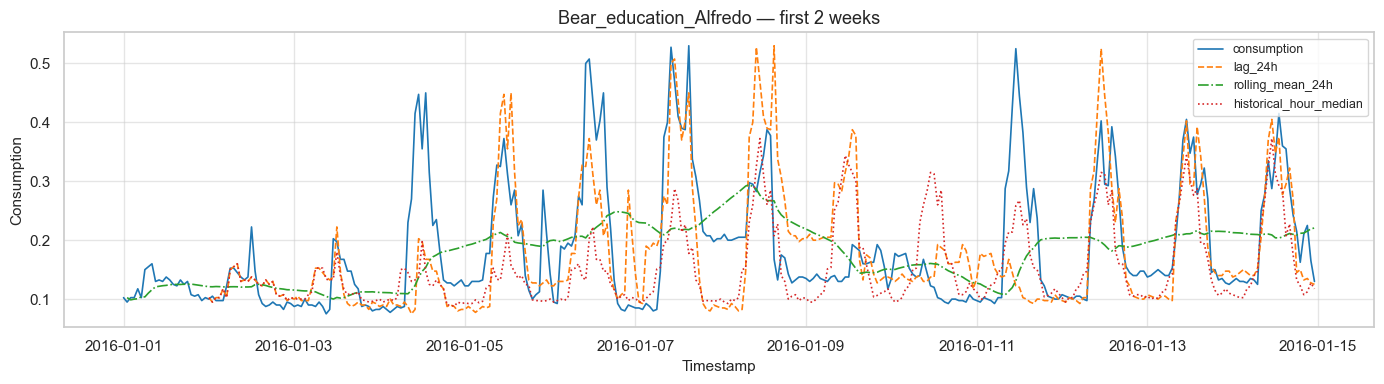

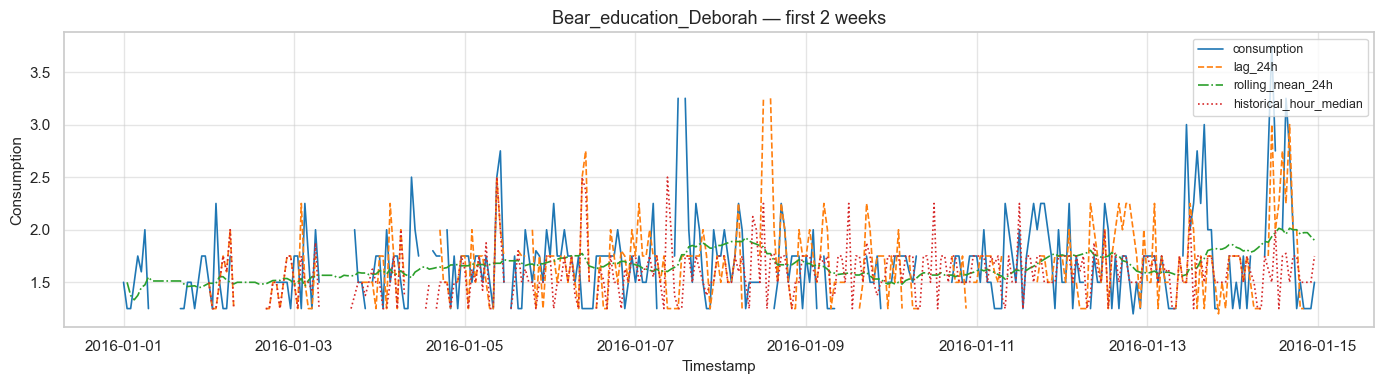

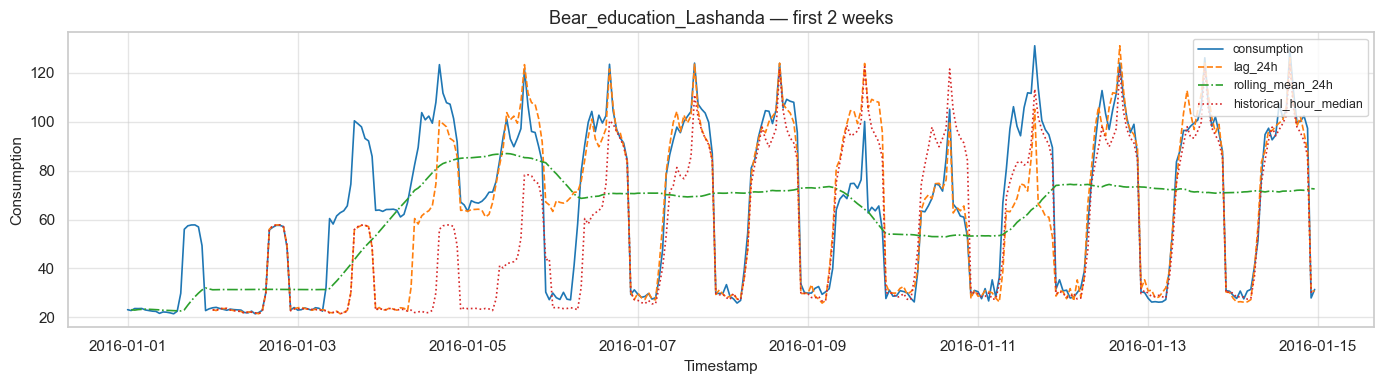

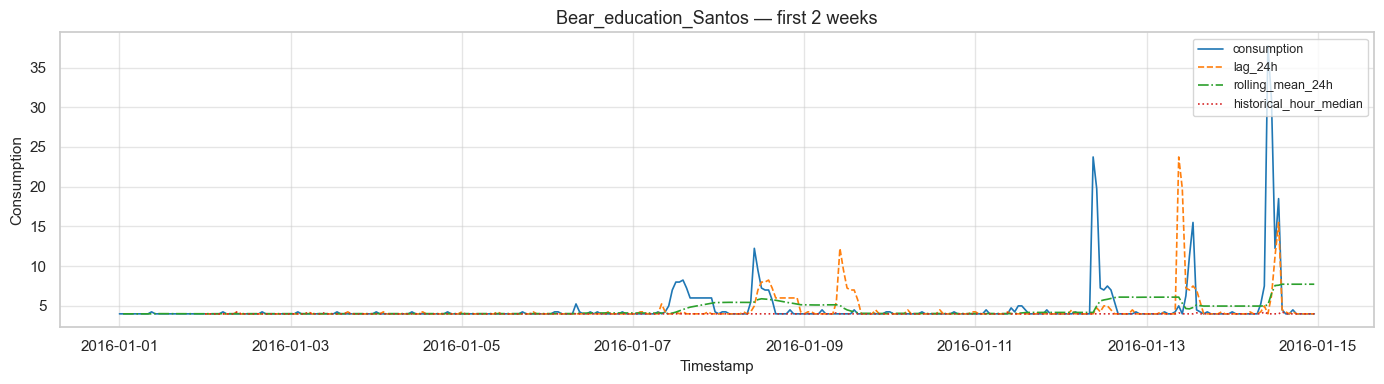

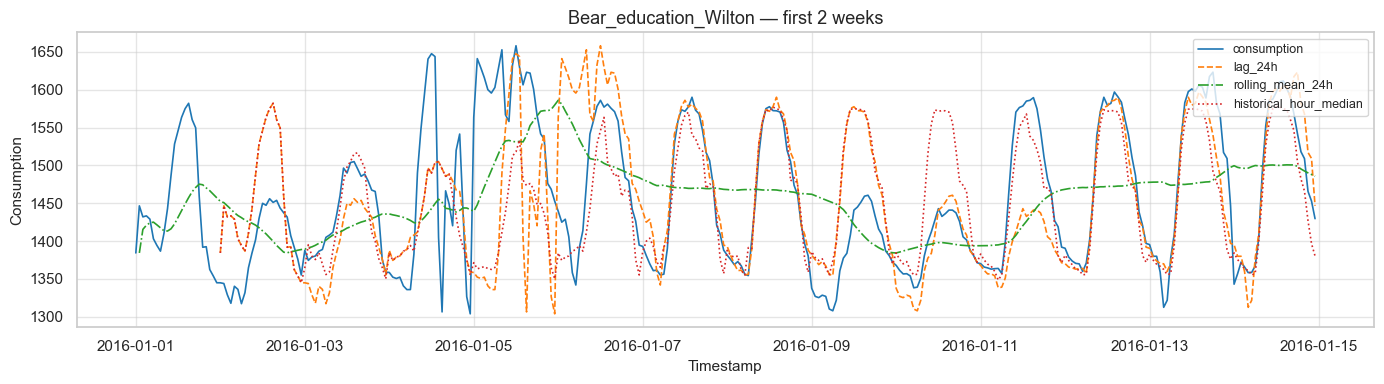

In [17]:
TARGET_NAMES  = ['Lashanda', 'Wilton', 'Alfredo', 'Santos', 'Deborah']
OVERLAY_COLS  = ['consumption', 'lag_24h', 'rolling_mean_24h', 'historical_hour_median']
OVERLAY_STYLE = ['-', '--', '-.', ':']

rep_buildings = [
    b for b in long_df['building_id'].unique()
    if any(b.endswith(f'_{n}') for n in TARGET_NAMES)
]

print(f'Representative buildings found: {rep_buildings}')

for bld in rep_buildings:
    bld_data = (
        long_df[long_df['building_id'] == bld]
        .sort_values('timestamp')
        .head(24 * 14)  # first 2 weeks
    )

    fig, ax = plt.subplots(figsize=(14, 4))
    for col, style in zip(OVERLAY_COLS, OVERLAY_STYLE):
        ax.plot(
            bld_data['timestamp'], bld_data[col],
            linestyle=style, label=col, linewidth=1.2,
        )
    ax.set_title(f'{bld} — first 2 weeks')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Consumption')
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

if not rep_buildings:
    print('None of the target buildings found. Check that building_id ends with _<Name>.')

---
## 16. Final Feature Inventory

In [18]:
feature_groups = {
    'Calendar features': [
        'hour', 'day_of_week', 'month', 'quarter',
        'year', 'day_of_year', 'week_of_year', 'is_weekend',
        'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    ],
    'Lag features': [
        'lag_1h', 'lag_24h', 'lag_168h',
    ],
    'Rolling features': [
        'rolling_mean_24h', 'rolling_median_24h', 'rolling_std_24h',
        'rolling_mean_168h', 'rolling_median_168h', 'rolling_std_168h',
    ],
    'Baseline features': [
        'historical_hour_median', 'historical_hour_mean', 'historical_hour_std',
        'historical_hour_daytype_median',
        'delta_1h', 'pct_change_1h', 'delta_24h', 'pct_change_24h',
        'building_mean', 'building_median', 'building_std', 'building_p95', 'building_p99',
    ],
    'Metadata features': [
        c for c in ['site_id', 'primaryspaceusage', 'sqm', 'lat', 'lng', 'timezone']
        if c in long_df.columns
    ],
}
if 'consumption_per_sqm' in long_df.columns:
    feature_groups['Baseline features'].append('consumption_per_sqm')

total_features = 0
for group, cols in feature_groups.items():
    present = [c for c in cols if c in long_df.columns]
    total_features += len(present)
    print(f'\n{group} ({len(present)})')
    for c in present:
        print(f'  • {c}')

print(f'\n{"-"*40}')
print(f'Total rows     : {len(long_df):,}')
print(f'Total columns  : {len(long_df.columns):,}')
print(f'Feature count  : {total_features}')


Calendar features (12)
  • hour
  • day_of_week
  • month
  • quarter
  • year
  • day_of_year
  • week_of_year
  • is_weekend
  • hour_sin
  • hour_cos
  • month_sin
  • month_cos

Lag features (3)
  • lag_1h
  • lag_24h
  • lag_168h

Rolling features (6)
  • rolling_mean_24h
  • rolling_median_24h
  • rolling_std_24h
  • rolling_mean_168h
  • rolling_median_168h
  • rolling_std_168h

Baseline features (14)
  • historical_hour_median
  • historical_hour_mean
  • historical_hour_std
  • historical_hour_daytype_median
  • delta_1h
  • pct_change_1h
  • delta_24h
  • pct_change_24h
  • building_mean
  • building_median
  • building_std
  • building_p95
  • building_p99
  • consumption_per_sqm

Metadata features (6)
  • site_id
  • primaryspaceusage
  • sqm
  • lat
  • lng
  • timezone

----------------------------------------
Total rows     : 27,684,432
Total columns  : 44
Feature count  : 41


---
## 17. Export

Write the full feature matrix to parquet for Stage 3 consumption.

In [19]:
STAGE2_OUT = Path('../../outputs/stage2_features.parquet')
STAGE2_OUT.parent.mkdir(parents=True, exist_ok=True)
long_df.to_parquet(STAGE2_OUT, index=False)

print(f'Exported {len(long_df):,} rows × {len(long_df.columns)} columns')
print(f'File : {STAGE2_OUT}')

Exported 27,684,432 rows × 44 columns
File : ..\..\outputs\stage2_features.parquet
